### 图像特征拓展

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### 图像特征拓展 – 纹理

In [2]:
# 边缘密度（Edge Density）:图像中边缘的多少反映纹理复杂度
def texture_edge_density(img_path):
    # 读取文件
    img = cv2.imread(img_path)
    
    # 图像从彩色（BGR）转换为灰度图，仅保留亮度信息，便于后续做边缘检测。
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    
    # cv2.Canny() 是 OpenCV 中的 Canny 边缘检测函数；它返回一个二值图像，边缘的像素值为 255，其他为 0；threshold1 和 threshold2 控制边缘的敏感度（可以调节）
    edges = cv2.Canny(gray,threshold1 = 100,threshold2 = 200)

    # 计算边缘像素数量
    edge_pixels = np.sum(edges > 0)

    # 图像的高度 × 宽度 = 总像素数量；
    total_pixels = img.shape[0]*img.shape[1]

    # 得到边缘密度
    # 得到边缘像素所占比例，数值越大表示图像中边缘越多，纹理越复杂；
    return edge_pixels/total_pixels

In [3]:
edge_ratio = texture_edge_density('5185d53bfdc9f03fd5001493.jpg')
edge_ratio

np.float64(0.10781666666666667)

In [4]:
# 可视化边缘密度检测
def show_edge_detection(img_path):
    # 读取图像
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    # 灰度图
    gray = cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)

    # canny边缘检测
    edges = cv2.Canny(gray,threshold1 = 100,threshold2 = 200)

    # 可视化
    plt.figure(figsize = (15,5))

    plt.subplot(1,3,1)
    plt.title('Original Image')
    plt.imshow(img_rgb)
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title('Grayscale Image')
    plt.imshow(gray,cmap = 'gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title('Canny Edges')
    plt.imshow(edges,cmap = 'gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

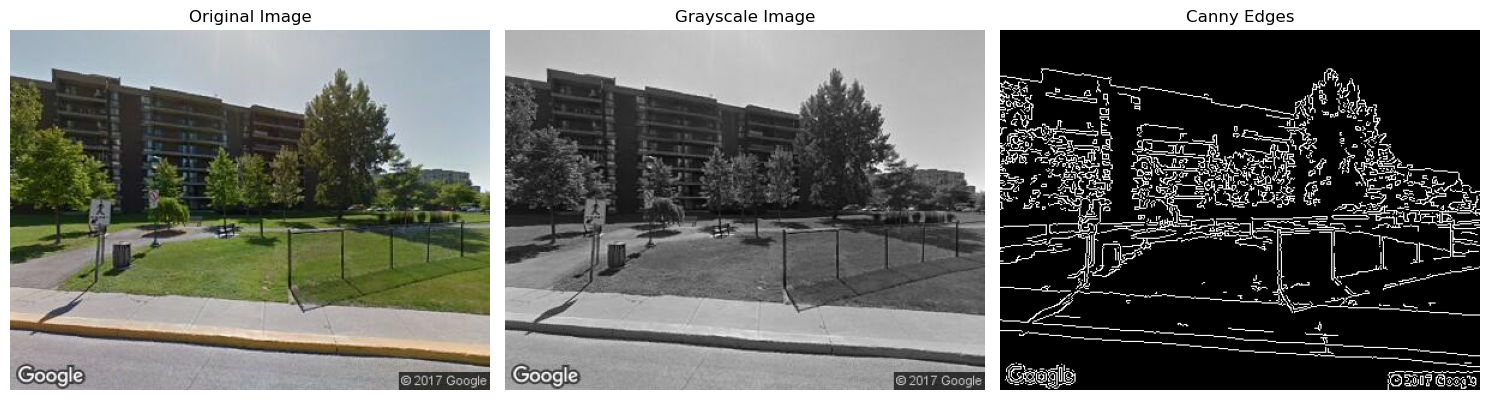

In [5]:
show_edge_detection('5185d53bfdc9f03fd5001493.jpg')

#### 图像特征拓展 – 清晰度

In [6]:
def clarity_score(img_path):
    # 读取图像
    img = cv2.imread(img_path)

    # 转为灰度
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    # Laplacian 算子是一种边缘检测方法，用于检测图像中快速变化的区域（也就是边缘）。
    # 它比 Sobel/Canny 更关注强度变化率，适合判断图像是否“模糊”。
    laplacian_var = cv2.Laplacian(gray,cv2.CV_64F).var()
    
    # ddepth：输出图像的数据深度，这里用 cv2.CV_64F 是为了保留足够的精度（尤其是负数）
    
    # .var()
    # 这是 NumPy 中的 .var() 方法，表示 方差。
    # 表示整个 Laplacian 图的像素值变化程度。

    # 值大：图像边缘丰富 -》 清晰度高；
    # 值小：图像边缘平滑、模糊 -》 说明图像不清晰。
    
    return laplacian_var

In [7]:
clarity = clarity_score('5185d53bfdc9f03fd5001493.jpg')
clarity

np.float64(1484.4319416649305)

#### 图像特征拓展 – 混乱度

衡量思路（结合课程已有方法）：

1. 语义分割后统计元素数量（例如图像里出现了几类物体）；
2. 局部复杂度指标（如边缘数量 + 颜色种类）；
3. 重叠区域面积（例如建筑+电线+车密集区域）；
4. 视觉注意力估计（高对比区域的密集度）– 拓展方向。

### 两种线性降维方法:PCA(非监督)和LDA(监督)

In [8]:
data = pd.read_csv('imgs_data.csv')
data.head()

,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,cluster_centers_rgb,color_ratios_raw,cluster_centers_hsv,matched_colors_raw,matched_colors,...,purple_ratio,black_ratio,white_ratio,gray_ratio,color_number,road,vegetation,building,clarity,texture_density
0,0,0,0,0,0,[[153 160 165]\n [ 22 80 129]\n [127 123 111]...,[0.34035833 0.03794167 0.32735833 0.1571 0...,"[array([103, 19, 165], dtype=uint8), array([1...","['gray', 'cyan', 'orange', 'gray', 'yellow']","['gray', 'cyan', 'orange', 'yellow']",...,0.0,0.0,0.000000,0.497458,4,30.108643,8.288574,14.099121,1695.431309,0.109367
1,1,1,1,1,1,[[ 36 35 26]\n [171 174 177]\n [ 93 96 66]...,[0.27780833 0.1731 0.21171667 0.1403 0...,"[array([27, 71, 36], dtype=uint8), array([105,...","['yellow', 'gray', 'yellow', 'orange', 'yellow']","['yellow', 'gray', 'orange']",...,0.0,0.0,0.000000,0.173100,3,11.358643,49.255371,1.159668,1793.139442,0.091800
2,2,2,2,2,2,[[153 148 121]\n [ 53 54 32]\n [214 215 209]...,[0.202775 0.20121667 0.1415 0.24424167 0...,"[array([ 25, 53, 153], dtype=uint8), array([ ...","['yellow', 'yellow', 'white', 'cyan', 'yellow']","['yellow', 'white', 'cyan']",...,0.0,0.0,0.141500,0.000000,3,25.579834,27.362061,4.821777,3981.626890,0.171992
3,3,3,3,3,3,[[ 68 72 69]\n [204 205 204]\n [157 159 158]...,[0.24099167 0.27510833 0.28238333 0.09298333 0...,"[array([68, 14, 72], dtype=uint8), array([ 60,...","['gray', 'white', 'gray', 'gray', 'yellow']","['gray', 'white', 'yellow']",...,0.0,0.0,0.275108,0.616358,3,31.072998,9.954834,26.251221,2593.127151,0.117633
4,4,4,4,4,4,[[ 52 54 33]\n [143 140 133]\n [203 205 204]...,[0.23179167 0.2211 0.0928 0.12643333 0...,"[array([33, 99, 54], dtype=uint8), array([ 21,...","['yellow', 'gray', 'white', 'gray', 'gray']","['yellow', 'gray', 'white']",...,0.0,0.0,0.092800,0.675408,3,24.835205,19.970703,19.769287,2377.207408,0.151850


In [9]:
edge_density_list = []
clarity_list = []

for filename in data['filename'].tolist():
    imagepath = f'/Users/zhaojunran/Documents/Python_Urban_Perception_and_Visual_Character/MIT_Place_Pulse_archive/gsv/final_photo_dataset/{filename}'
    
    edge_density = texture_edge_density(imagepath)
    edge_density_list.append(edge_density)
    
    clarity = clarity_score(imagepath)
    clarity_list.append(clarity)

In [10]:
data['clarity'] = clarity_list
data['edge_density'] = edge_density_list

In [11]:
data.to_csv('20251103.csv')

In [12]:
data.head()

,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,cluster_centers_rgb,color_ratios_raw,cluster_centers_hsv,matched_colors_raw,matched_colors,...,black_ratio,white_ratio,gray_ratio,color_number,road,vegetation,building,clarity,texture_density,edge_density
0,0,0,0,0,0,[[153 160 165]\n [ 22 80 129]\n [127 123 111]...,[0.34035833 0.03794167 0.32735833 0.1571 0...,"[array([103, 19, 165], dtype=uint8), array([1...","['gray', 'cyan', 'orange', 'gray', 'yellow']","['gray', 'cyan', 'orange', 'yellow']",...,0.0,0.000000,0.497458,4,30.108643,8.288574,14.099121,1695.431309,0.109367,0.109367
1,1,1,1,1,1,[[ 36 35 26]\n [171 174 177]\n [ 93 96 66]...,[0.27780833 0.1731 0.21171667 0.1403 0...,"[array([27, 71, 36], dtype=uint8), array([105,...","['yellow', 'gray', 'yellow', 'orange', 'yellow']","['yellow', 'gray', 'orange']",...,0.0,0.000000,0.173100,3,11.358643,49.255371,1.159668,1793.139442,0.091800,0.091800
2,2,2,2,2,2,[[153 148 121]\n [ 53 54 32]\n [214 215 209]...,[0.202775 0.20121667 0.1415 0.24424167 0...,"[array([ 25, 53, 153], dtype=uint8), array([ ...","['yellow', 'yellow', 'white', 'cyan', 'yellow']","['yellow', 'white', 'cyan']",...,0.0,0.141500,0.000000,3,25.579834,27.362061,4.821777,3981.626890,0.171992,0.171992
3,3,3,3,3,3,[[ 68 72 69]\n [204 205 204]\n [157 159 158]...,[0.24099167 0.27510833 0.28238333 0.09298333 0...,"[array([68, 14, 72], dtype=uint8), array([ 60,...","['gray', 'white', 'gray', 'gray', 'yellow']","['gray', 'white', 'yellow']",...,0.0,0.275108,0.616358,3,31.072998,9.954834,26.251221,2593.127151,0.117633,0.117633
4,4,4,4,4,4,[[ 52 54 33]\n [143 140 133]\n [203 205 204]...,[0.23179167 0.2211 0.0928 0.12643333 0...,"[array([33, 99, 54], dtype=uint8), array([ 21,...","['yellow', 'gray', 'white', 'gray', 'gray']","['yellow', 'gray', 'white']",...,0.0,0.092800,0.675408,3,24.835205,19.970703,19.769287,2377.207408,0.151850,0.151850


In [13]:
data.columns

Index(['Unnamed: 0.4', 'Unnamed: 0.3', 'Unnamed: 0.2', 'Unnamed: 0.1',
       'Unnamed: 0', 'cluster_centers_rgb', 'color_ratios_raw',
       'cluster_centers_hsv', 'matched_colors_raw', 'matched_colors',
       'color_ratios_matched', 'filename', 'h_mean', 'h_std', 's_mean',
       'v_mean', 'v_max', 'place_id', 'simple_score_safety',
       'elo_score_safety', 'elo_score_lively', 'simple_score_lively',
       'green_ratio', 'red_ratio', 'orange_ratio', 'yellow_ratio',
       'cyan_ratio', 'blue_ratio', 'purple_ratio', 'black_ratio',
       'white_ratio', 'gray_ratio', 'color_number', 'road', 'vegetation',
       'building', 'clarity', 'texture_density', 'edge_density'],
      dtype='object')

In [14]:
# 清理 data 中的无穷大值，将其转换为缺失值，然后移除包含缺失值的行，以得到一个不包含无穷大值和缺失值的 DataFrame。
data = data.replace([np.inf,-np.inf],np.nan).dropna()

# replace([np.inf, -np.inf], np.nan)：这一步使用 replace 方法将 data 中所有的正无穷大（np.inf）和负无穷大（-np.inf）值替换为 np.nan，即缺失值。
# 例如，在引用[3]中，使用 df.replace(np.inf, np.nan) 将 DataFrame 中的正无穷大值替换为缺失值。
# 这里 data.replace([np.inf, -np.inf], np.nan) 是同时处理正无穷和负无穷的情况。

# dropna()：在完成无穷大值替换为缺失值的操作后，使用 dropna 方法移除包含缺失值的行或列。

In [15]:
X=data[[ 'h_mean', 'h_std', 's_mean', 'v_mean', 'v_max', 'green_ratio', 'red_ratio', 'orange_ratio',
       'yellow_ratio', 'cyan_ratio', 'blue_ratio', 'purple_ratio',
       'black_ratio', 'white_ratio', 'gray_ratio', 'color_number', 'road',
       'vegetation', 'building', 'clarity', 'texture_density']]

In [16]:
y = data[['simple_score_safety', 'elo_score_safety', 'elo_score_lively','simple_score_lively']]

#### 主成分分析（PCA) | 无监督学习

PCA 的计算流程：

1. 先对每列特征减去均值（中心化），除以标准差（标准化），这样每列均值为0、方差为1。
2. 计算协方差矩阵
3. 特征值分解（或奇异值分解）：对协方差矩阵进行特征值分解，得到：
- 特征向量（表示主成分方向）
- 特征值（表示主成分的重要性）
4. 选择前 k 个主成分： 根据特征值大小排序，通常选择能解释 >80%~95% 总方差的前几个作为主成分。

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 标准化特征:先对每列特征减去均值（中心化），除以标准差（标准化），这样每列均值为0、方差为1。
scaler = StandardScaler()
X_std = scaler.fit_transform(X) # 均值为0，方差为1

# PCA降维
pca = PCA(n_components = 12) # 1. 实例化 PCA，保留12个主成分
X_pca = pca.fit_transform(X_std) # 2. 拟合 + 转换标准化后的数据 

# 为什么n_components = 12呢?因为尝试了从1开始,直到12才满足解释大部分数据
# 要尽可能的让主成分解释方差比例的和接近90% - 这个时候的主成分数是比较合理的,能代表大部分数据
# 累计解释方差超过 90% -》足够保留主要信息！

# X_pca = pca.fit_transform(X_std) 这行代码是在使用 scikit-learn 库中的主成分分析（PCA）方法对标准化后的数据 X_std 进行降维处理。

# fit_transform 是一个组合操作，它完成了两个主要步骤：
# fit：使用数据 X_std 来训练 PCA 模型，即计算数据的主成分。PCA 会找到数据中方差最大的方向，这些方向就是主成分。
# transform：将原始数据 X_std 转换到新的主成分空间，得到降维后的数据。

print("解释方差比例:", pca.explained_variance_ratio_) # 表示 每个主成分解释了原始数据中多少比例的方差，是 PCA 中非常关键的指标。

解释方差比例: [0.18891458 0.13169074 0.08747763 0.08269335 0.06607785 0.05625899
 0.0547537  0.05245972 0.04795328 0.04565302 0.04413362 0.03688477]


In [18]:
features = [ 'h_mean', 'h_std', 's_mean', 'v_mean', 'v_max', 'green_ratio', 'red_ratio', 'orange_ratio',
       'yellow_ratio', 'cyan_ratio', 'blue_ratio', 'purple_ratio',
       'black_ratio', 'white_ratio', 'gray_ratio', 'color_number', 'road',
       'vegetation', 'building', 'clarity', 'texture_density']
loadings = pd.DataFrame(pca.components_.T,columns = [f'PCA{i+1}' for i in range(pca.n_components)], index = features)

# 用loadings看一下哪一些列比较重要

# pca.components_: 返回加载矩阵”（loading matrix），每一行代表一个主成分，每列代表一个原始特征的权重（也就是主成分中各特征的“贡献度”）, 
# 系数绝对值越大，说明该特征对这个主成分的“影响”越大
# PCAi = feature1 * loading1 + feature2 * loading2 + …. featuren * loadingn
# vegetation 是 PC1 的主要构成，但不是唯一成分
# PCA1 是一个新的“综合特征”，不能说它=vegetation
loadings

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10,PCA11,PCA12
h_mean,0.043036,1.738834e-01,-1.725083e-01,0.581924,-1.087122e-01,7.241071e-02,-9.299258e-02,1.926615e-01,-1.192433e-01,-0.239225,-7.992659e-02,-1.443589e-01
h_std,-0.065121,5.277124e-02,-6.776555e-02,0.318636,3.499453e-01,3.608936e-01,-3.424927e-01,1.619240e-01,-1.791635e-01,0.356709,1.299449e-01,-3.821353e-01
s_mean,0.363010,-2.819250e-01,8.796729e-02,-0.007946,-2.031901e-01,1.206182e-01,-1.250186e-01,5.097449e-02,4.925435e-02,-0.033625,-3.097048e-02,-8.220770e-02
v_mean,-0.208538,-2.797616e-01,-3.310642e-01,0.032184,2.065319e-01,2.979483e-02,-9.396053e-02,-1.710199e-01,-6.668174e-02,-0.328337,-1.492634e-01,8.556332e-03
v_max,-0.000000,-1.110223e-16,-1.387779e-17,-0.000000,4.163336e-17,-2.775558e-17,5.551115e-17,-8.326673e-17,1.110223e-16,0.000000,9.714451e-17,1.110223e-16
green_ratio,0.323383,2.124770e-01,-1.247389e-01,0.149426,-3.729023e-01,-1.354965e-01,3.205975e-03,-1.849488e-01,2.073431e-01,0.105979,2.939668e-02,-7.491496e-02
red_ratio,-0.031776,-4.328226e-03,2.295502e-01,0.170550,1.083708e-01,3.601103e-01,-3.561242e-01,-7.374971e-02,6.516571e-01,0.046423,-7.755598e-04,3.838354e-01
orange_ratio,-0.111303,-3.926458e-01,1.868029e-01,-0.131836,-2.146938e-02,1.710917e-02,-1.819059e-01,-3.808358e-01,-2.754293e-01,0.330381,1.459229e-01,-1.268816e-01
yellow_ratio,0.138384,-1.692487e-01,-2.970869e-02,-0.338093,3.815220e-01,1.407930e-01,2.359198e-01,5.097820e-01,1.966276e-01,-0.100549,-8.191175e-02,-1.549103e-01
cyan_ratio,-0.010708,-4.232806e-01,-3.422001e-02,0.216715,-3.092664e-01,5.344829e-02,-1.308172e-01,2.062348e-01,-1.573725e-01,-0.348604,-9.307128e-02,1.103727e-01


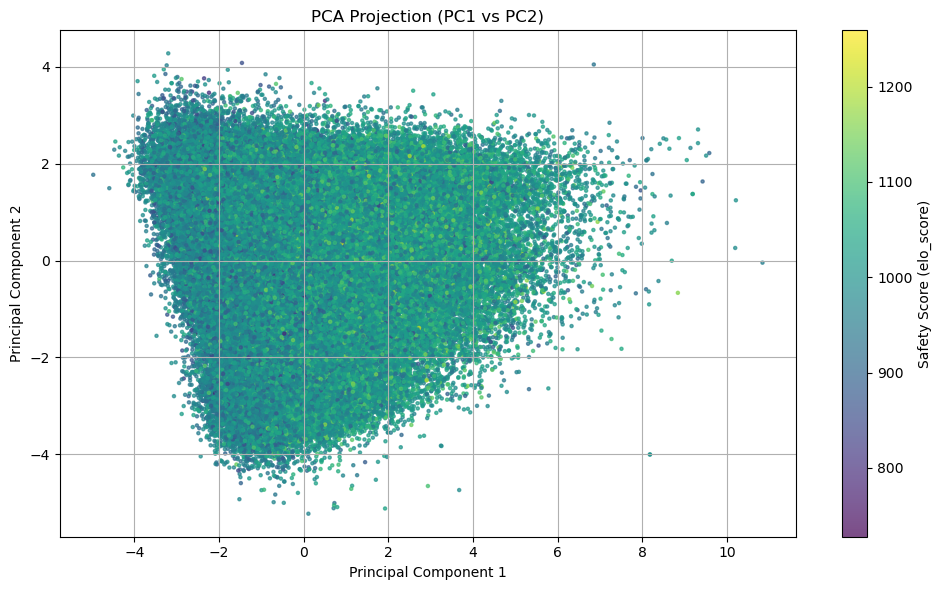

In [19]:
# 可视化

pca_df = pd.DataFrame(X_pca,columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]) # X_pca.shape[1] 表示 X_pca 的列数，也就是主成分的数量
pca_df['elo_score'] = y['elo_score_safety'].values  # 添加原始的安全评分作为颜色

# 使用前两个主成分做可视化
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    pca_df['PC1'], pca_df['PC2'],
    c=pca_df['elo_score'], cmap='viridis', s=5, alpha=0.7
)
plt.colorbar(scatter, label='Safety Score (elo_score)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection (PC1 vs PC2)')
plt.grid(True)
plt.tight_layout()
plt.show()

这个主成分并不是分析的很好

#### LDA（线性判别分析, Linear Discriminant Analysis）监督学习

同类数据尽可能近,不同数据尽可能远

In [20]:
import pandas as pd

In [24]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 定义了2个维度
lda = LinearDiscriminantAnalysis(n_components = 2)
# 这行代码创建了一个 LinearDiscriminantAnalysis 类的实例 lda。LinearDiscriminantAnalysis 是线性判别分析模型，用于数据的降维和分类。
# n_components = 2 表示将原始数据降维到二维空间，即把原始特征数据转换为二维特征数据，以便于可视化或减少数据维度

# 分成了4个类别
y_cat = pd.qcut(y['elo_score_safety'],q = 4,labels = [0,1,2,3]) # 按分位数切 4 类 # y_cat 是类别标签
# 这行代码使用 pandas 库的 qcut 函数对 y 数据框中的 elo_score_safety 列进行分箱操作。q = 3 表示将该列的数据按照分位数均匀地划分为3个区间，
# labels = [0, 1, 2] 表示为每个区间分配一个类别标签，分别为 0、1、2。
# 最终结果存储在 y_cat 中，y_cat 是一个包含分类标签的 Series 对象。

# 训练降维
X_lda = lda.fit_transform(X,y_cat)
# 这行代码调用 lda 对象的 fit_transform 方法。
# fit 过程是让线性判别分析模型根据输入的特征矩阵 X 和对应的类别标签 y_cat 来学习数据的特征和类别之间的关系，找到最优的投影方向；
# transform 过程则是根据学习到的投影方向，将原始特征矩阵 X 转换为降维后的二维特征矩阵。最终降维后的矩阵存储在 X_cat 中。

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
import shap
import pandas as pd

# 训练一个回归模型 | 可以换成XGBoost
model = RandomForestRegressor(n_estimators = 100,random_state = 42)
model.fit(X_pca,y['elo_score_safety'].values)

#使用shap分析主成分的贡献
explainer = shap.Explainer(model,X_pca)
shap_values = explainer(X_pca)

# beeswarm图展示每个主成分的重要性
shap.plots.beeswarm(shap_values,show = True)

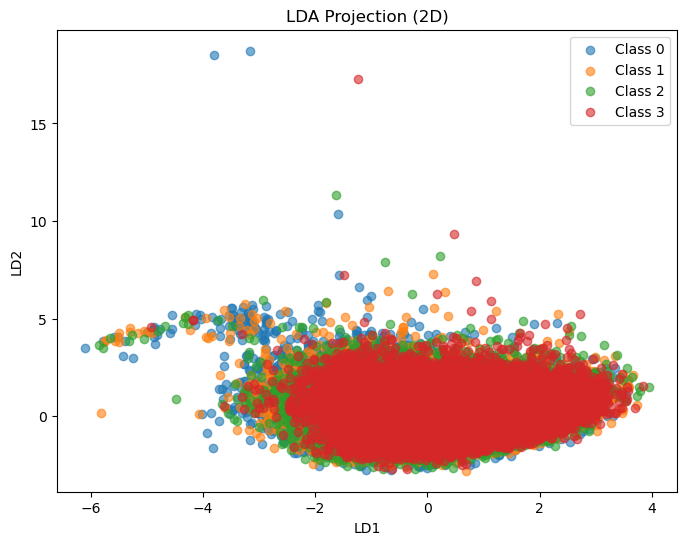

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
for label in np.unique(y_cat):
    plt.scatter(X_lda[y_cat == label, 0], X_lda[y_cat == label, 1], label=f"Class {label}", alpha=0.6)
    # X_lda 是经过线性判别分析（LDA）降维后的数据矩阵。y_cat == label 是一个布尔索引，用于筛选出类别标签等于 label 的数据点。
    # [y_cat == label, 0] 表示从这些筛选出的数据点中选取第一列（索引为 0）作为散点图的 x 坐标。
    # X_lda[y_cat == label, 1]：同样基于布尔索引筛选出类别标签等于 label 的数据点，然后选取第二列（索引为 1）作为散点图的 y 坐标。
plt.title("LDA Projection (2D)")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.show()

虽然这部分数据也没有分的特别开,但是在一开始还是有分开一些的

当遇到现在这样的表现不太好的情况,就继续更换降维方法